In [67]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.sans-serif"] = "stix"

In [28]:
import numpy as np

In [3]:
import sympy

In [2]:
sympy.init_printing()

In [62]:
from scipy import optimize

In [63]:
from scipy import optimize

------------------------------------------

In [5]:
r, h = sympy.symbols("r, h")

In [6]:
Area = 2 * sympy.pi * r**2 + 2 * sympy.pi * r * h

In [7]:
Area

2*pi*h*r + 2*pi*r**2

In [8]:
Volume = sympy.pi * r**2 * h

In [9]:
Volume

pi*h*r**2

In [13]:
h_r = sympy.solve(Volume - 1)[0]

In [14]:
h_r

{h: 1/(pi*r**2)}

In [15]:
Area_r = Area.subs(h_r)

In [16]:
Area_r

2*pi*r**2 + 2/r

In [17]:
rsol = sympy.solve(Area_r.diff(r))[0]

In [18]:
rsol

2**(2/3)/(2*pi**(1/3))

In [23]:
rsol.evalf()

0.541926070139289

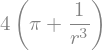

In [45]:
# verify that the second derivative is positive, so that rsol is a minimum
Area_r.diff(r, 2).subs(r, rsol)

In [46]:
Area_r.diff(r, 2).subs(r, rsol)

In [17]:
_.evalf()

In [18]:
def f(r):
    return 2 * np.pi * r**2 + 2 / r

In [21]:
r_min = optimize.brent(f, brack=(0.1, 4))

In [22]:
r_min

In [23]:
f(r_min)

In [24]:
optimize.minimize_scalar(f, bracket=(0.1, 4))

 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: 5.535810445932086
       x: 0.5419260772557135
     nit: 15
    nfev: 18

In [35]:
r = np.linspace(0, 2, 100)
#r = np.linspace(0, 2, 100)[-1]

In [36]:
r

array([0.        , 0.02020202, 0.04040404, 0.06060606, 0.08080808,
       0.1010101 , 0.12121212, 0.14141414, 0.16161616, 0.18181818,
       0.2020202 , 0.22222222, 0.24242424, 0.26262626, 0.28282828,
       0.3030303 , 0.32323232, 0.34343434, 0.36363636, 0.38383838,
       0.4040404 , 0.42424242, 0.44444444, 0.46464646, 0.48484848,
       0.50505051, 0.52525253, 0.54545455, 0.56565657, 0.58585859,
       0.60606061, 0.62626263, 0.64646465, 0.66666667, 0.68686869,
       0.70707071, 0.72727273, 0.74747475, 0.76767677, 0.78787879,
       0.80808081, 0.82828283, 0.84848485, 0.86868687, 0.88888889,
       0.90909091, 0.92929293, 0.94949495, 0.96969697, 0.98989899,
       1.01010101, 1.03030303, 1.05050505, 1.07070707, 1.09090909,
       1.11111111, 1.13131313, 1.15151515, 1.17171717, 1.19191919,
       1.21212121, 1.23232323, 1.25252525, 1.27272727, 1.29292929,
       1.31313131, 1.33333333, 1.35353535, 1.37373737, 1.39393939,
       1.41414141, 1.43434343, 1.45454545, 1.47474747, 1.49494

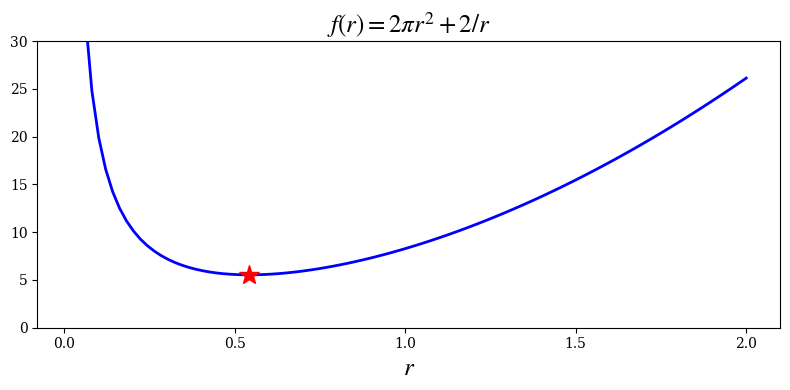

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(r, f(r), lw=2, color="b")
ax.plot(r_min, f(r_min), "r*", markersize=15)
ax.set_title(r"$f(r) = 2\pi r^2+2/r$", fontsize=18)
ax.set_xlabel(r"$r$", fontsize=18)
ax.set_xticks([0, 0.5, 1, 1.5, 2])
ax.set_ylim(0, 30)

fig.tight_layout()
fig.savefig("ch6-univariate-optimization-example.pdf")

-----------------------------------------------------------------------------

In [38]:
x1, x2 = sympy.symbols("x_1, x_2")

In [39]:
f_sym = (x1 - 1) ** 4 + 5 * (x2 - 1) ** 2 - 2 * x1 * x2

In [40]:
f_sym

-2*x_1*x_2 + (x_1 - 1)**4 + 5*(x_2 - 1)**2

In [41]:
fprime_sym = [f_sym.diff(x_) for x_ in (x1, x2)]

In [46]:
fprime_sym[0]

-2*x_2 + 4*(x_1 - 1)**3

In [47]:
fprime_sym[1]

-2*x_1 + 10*x_2 - 10

In [48]:
# Gradient
sympy.Matrix(fprime_sym)

Matrix([
[-2*x_2 + 4*(x_1 - 1)**3],
[   -2*x_1 + 10*x_2 - 10]])

In [50]:
fhess_sym = [[f_sym.diff(x1_, x2_) for x1_ in (x1, x2)] for x2_ in (x1, x2)]

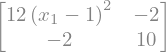

In [55]:
# Hessian
sympy.Matrix(fhess_sym)

In [55]:
f_lmbda = sympy.lambdify((x1, x2), f_sym, "numpy")

In [58]:
fprime_lmbda = sympy.lambdify((x1, x2), fprime_sym, "numpy")

In [57]:
fhess_lmbda = sympy.lambdify((x1, x2), fhess_sym, "numpy")

In [52]:
def func_XY_X_Y(f):
    """
    Wrapper for f(X) -> f(X[0], X[1])
    """
    return lambda X: np.array(f(X[0], X[1]))

In [53]:
f = func_XY_X_Y(f_lmbda)

In [59]:
fprime = func_XY_X_Y(fprime_lmbda)

In [60]:
fhess = func_XY_X_Y(fhess_lmbda)

In [64]:
X_opt = optimize.fmin_ncg(f, (0.0, 0), fprime=fprime, fhess=fhess)

Optimization terminated successfully.
         Current function value: -3.867223
         Iterations: 8
         Function evaluations: 10
         Gradient evaluations: 10
         Hessian evaluations: 8


In [65]:
X_opt

array([1.88292613, 1.37658523])

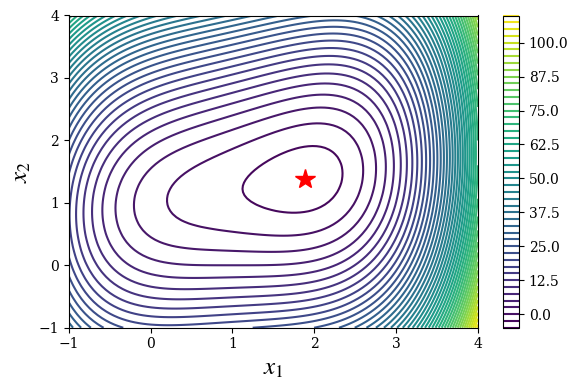

In [68]:
fig, ax = plt.subplots(figsize=(6, 4))
x_ = y_ = np.linspace(-1, 4, 100)
X, Y = np.meshgrid(x_, y_)
c = ax.contour(X, Y, f_lmbda(X, Y), 50)
ax.plot(X_opt[0], X_opt[1], "r*", markersize=15)
ax.set_xlabel(r"$x_1$", fontsize=18)
ax.set_ylabel(r"$x_2$", fontsize=18)
plt.colorbar(c, ax=ax)
fig.tight_layout()
fig.savefig("ch6-examaple-two-dim.pdf");

---------------------------------------------------------------------